In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u
from astropy import constants as const
from astropy.cosmology import Planck18, z_at_value

from scipy.integrate import quad
from scipy.optimize import curve_fit
#from ipynb.fs.full.Generator_trapz import *
#from ipynb.fs.full.Analytic_neutrino_flux import *
from GOALS_dataframe.analytic_neutrino_flux import *


import matplotlib.patches as patches


from gammapy.modeling.models import (
    EBL_DATA_BUILTIN,
    EBLAbsorptionNormSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)




In [ ]:
DL = 15.9 * u.Mpc
gammasn=4.52
RSN=0.56*0.5
alphaAGN=1.00
z = z_at_value(Planck18.luminosity_distance, DL)
redshift = z.value

franceschini17 = EBLAbsorptionNormSpectralModel.read_builtin(
    "franceschini17", redshift=redshift
)

energyrange=franceschini17.energy.value*1e-6
AbsCoeff=franceschini17.data.value[int(round(redshift,3)*1000)-1]
AbsCoeff=AbsCoeff[energyrange>0.1]

energyrange=energyrange[energyrange>0.1]




[1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
 1.000

0

In [3]:
#NGC1068_3 = [bulk_flux(i, 2500,250,150,500,0.1,1e10,4.11,1e8,0.28,50.7) for i in energy]
NGC1068_3a= Flux_gamma(energyrange, R=250,v=500,nism=2500,H=150,gammasn=gammasn,pmax=1e8,RSN=RSN,D_L=DL.value)*AbsCoeff*0.00160218 #to erg



In [4]:
dataNorth = pd.read_csv('CTAO_data/CTAOdata_North_50h.csv',sep=';', header=None, names=['X','Y'])
dataSouth = pd.read_csv('CTAO_data/CTAOdata_South_50h.csv',sep=';', header=None, names=['X','Y'])
dataNGC1068 = pd.read_csv('96/NGC1068_data.csv',sep=';', header=None, names=['X','Y'])
upperNGC1068 = pd.read_csv('96/NGC1068_upper.csv',sep=';', header=None, names=['X','Y'])
xyminNGC1068 = pd.read_csv('96/NGC1068_xymin.csv',sep=';', header=None, names=['X','Y']) #Uncertainty
xymaxNGC1068 = pd.read_csv('96/NGC1068_xymax.csv',sep=';', header=None, names=['X','Y'])
lowerleftNGC1068=pd.read_csv('96/NGC1068_lowerleft.csv',sep=';', header=None, names=['X','Y']) #Upper Uncertainty
rightNGC1068=pd.read_csv('96/NGC1068_right.csv',sep=';', header=None, names=['X','Y'])

tabdata=[dataNorth,dataSouth,dataNGC1068,upperNGC1068,xyminNGC1068,xymaxNGC1068,lowerleftNGC1068,rightNGC1068]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)

XNorth=dataNorth.X.astype('float64')*1e3 # to GeV
YNorth=dataNorth.Y.astype('float64')
XSouth=dataSouth.X.astype('float64')*1e3 # to GeV
YSouth=dataSouth.Y.astype('float64')

XNGC1068data=dataNGC1068.X.astype('float64')
YNGC1068data=dataNGC1068.Y.astype('float64')*0.00160218 #to erg
XminNGC1068data=xyminNGC1068.X.astype('float64')
YminNGC1068data=xyminNGC1068.Y.astype('float64')*0.00160218 #to erg
XmaxNGC1068data=xymaxNGC1068.X.astype('float64')
YmaxNGC1068data=xymaxNGC1068.Y.astype('float64')*0.00160218 #to erg

XNGC1068upper=upperNGC1068.X.astype('float64')
YNGC1068upper=upperNGC1068.Y.astype('float64')*0.00160218 #to erg
XminNGC1068upper=lowerleftNGC1068.X.astype('float64')
YminNGC1068upper=lowerleftNGC1068.Y.astype('float64')*0.00160218 #to erg
XmaxNGC1068upper=rightNGC1068.X.astype('float64')


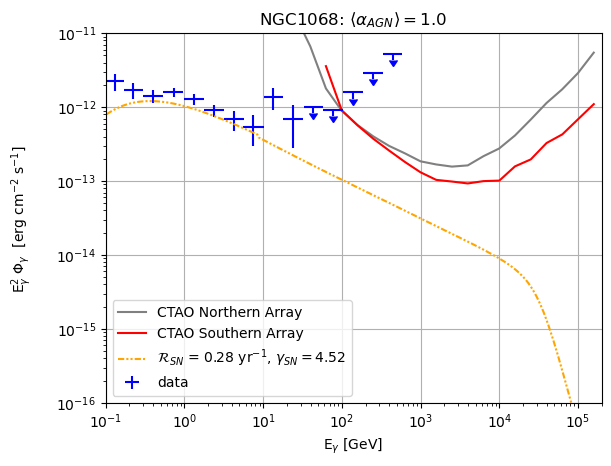

In [5]:
plt.plot(XNorth,YNorth,color="gray",label ="CTAO Northern Array")
plt.plot(XSouth,YSouth,color="red",label ="CTAO Southern Array")
plt.errorbar(XNGC1068data,YNGC1068data,xerr=[XNGC1068data-XminNGC1068data,XmaxNGC1068data-XNGC1068data], yerr=[YNGC1068data-YminNGC1068data,YmaxNGC1068data-YNGC1068data], color="blue",fmt=',',label='data')
plt.errorbar(XNGC1068upper,YNGC1068upper,xerr=[XNGC1068upper-XminNGC1068upper,XmaxNGC1068upper-XNGC1068upper], yerr=YNGC1068upper-YminNGC1068upper,color="blue",uplims=True,fmt=',')

plt.plot(energyrange,NGC1068_3a, color = 'orange',linestyle = (0,(3,1,1,1,1,1)),label='$\mathcal{R}_{SN}$ = '+str(RSN)+' yr$^{-1}$, $\\gamma_{SN} = $'+ str(gammasn) )






plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-1,2e5) ; plt.ylim(1e-16,1e-11)
#plt.xlim(2e2,2e8) ; plt.ylim(9e-16,5e-9) #nu
plt.title(r"NGC1068: $ \langle \alpha_{AGN}\rangle=$"+ str(alphaAGN))
plt.xlabel('E$_{\\gamma}$ [GeV] ')
plt.ylabel('E$_{\\gamma}^2$ $\\Phi_{\\gamma}$  [erg cm$^{-2}$ s$^{-1}$] \n')
plt.legend(loc = 'lower left')
plt.grid()

#plt.savefig("./Figures/FluxplotNGC1068.pdf",bbox_inches="tight",dpi = 200)
